<a href="https://colab.research.google.com/github/Tabatha651/METODOS_NUMERICOS/blob/main/MetodoPuntoFijo08Oct.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##MÉTODO PUNTO FIJO

Un número $p$ es un punto fijo para una función dada $g$ si se cumple la condición:

$$g(p)=p$$

Existe una relación directa entre los problemas de punto fijo y la busqueda de raíces de una ecuación de la forma $f(x)=0$, ya que es posible reescribir la ecuación original de diversas formas equivalentes mediante la forma de punto fijo:

$$x=g(x)$$

Para aproximar el punto fijo de una función $g$, elegimos una aproximación inicial $p_0$ y construimos una sucesión de la forma $p_n = g(p_{n-1})$ para cada $n>=1$

Si esta sucesión converge a un límite $p$ y la función $g$ es continua, se demuestra que $p=g(p)$, y así obtenemos una solución para $x=g(x)$

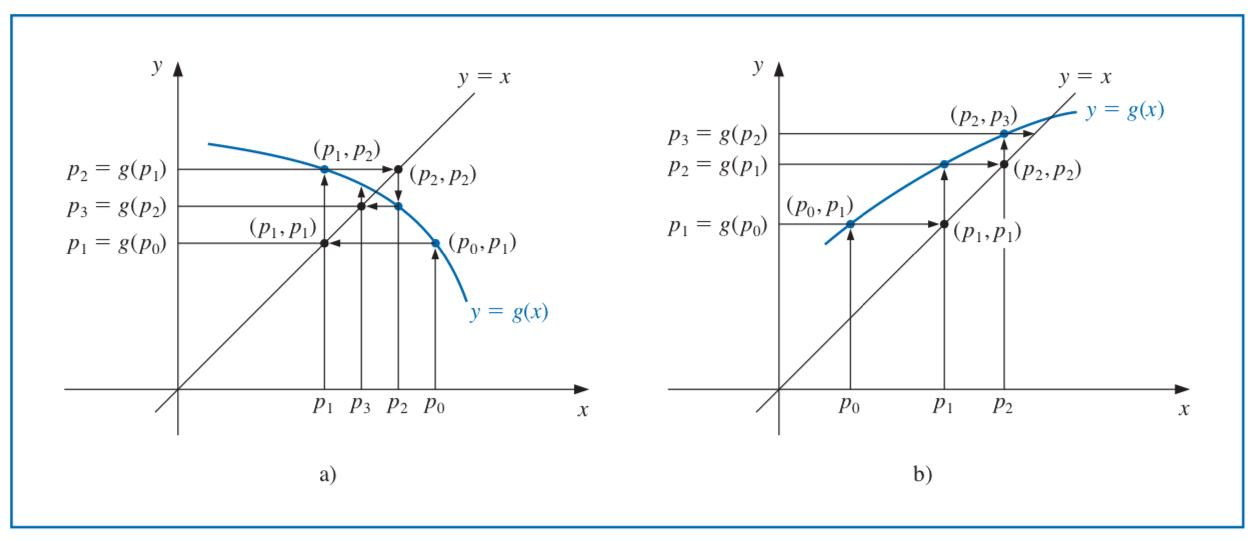

Como se ilustra en la imagen, un punto fijo ocurre precisamente en la intersección entre la curva de la función de iteración $y=g(x)$ y la recta identidad $y=x$

Para ilustrar el **Método De Punto Fijo** resolveremos la ecuación $x^3 + 4x^2 - 10 = 0$, la cual tiene una raíz en el intervalo $[1, 2]$

Manipulamos algebraicamente la ecuación para así obtener una forma de punto fijo:

$$x=g(x)$$

$$x = g_3(x) = \frac{1}{2}(10 - x^3)^{1/2}$$

Al transformar una ecuación $f(x)=0$ a la forma equivalente $x=g(x)$, es necesario seleccionar adecuadamente la función de iteración $g(x)$, ya que no todas garantizan que el método se acerque a la raíz


Algunas elecciones generan sucesiones que convergen rápidamente hacia la solución (como la opción que usaremos para la resolución de este ejemplo), pero otras pueden diverger o volverse indefinidas si involucran operaciones no válidas (ej. raíces cuadradas de num negativos)


El "éxito" del método depende en que la derivada de la función de iteración cumpla con la condición $\vert{}g'(x)\vert{}<1$ en un intervalo que se acerque a la raíz

(Puede funcionar a veces el método aunque no se cumplan las condiciones)

También podemos analizar que al elegir una función $g(x)$ las aproximaciones sucesivas $p_n=g(p_{n-1})$ reduzcan la distancia al punto fijo en cada iteración, asegurandonos así que el error absoluto disminuye hasta cumplir con la tolerancia que se establece

In [1]:
#06/oct/2026 - Prueba
from math import * #Importa funciones del módulo math
import matplotlib.pyplot as plt #Gráficos (usa alias plt)
import numpy as np #Importa biblioteca Numphy y asigna el alias np


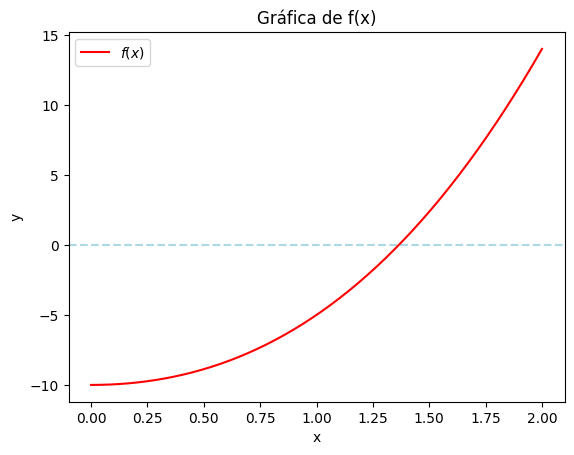

In [2]:
"""----------------------Gráfica f(x)-----------------------------"""
def f(x):
  return (x**3)+(4*x**2)-10


#Configurar el intervalo para la gráfica
x1=np.linspace(0,2)
plt.axhline(y=0, linestyle="--", color="lightblue")
#Graficar la función f(x)
plt.plot(x1, f(x1), color="red", label="$f(x)$")


#Etiquetas y ejes
plt.xlabel("x")
plt.ylabel("y")
plt.title("Gráfica de f(x)")


#Muestra leyenda
plt.legend()
#Muestra gráfico
plt.show()

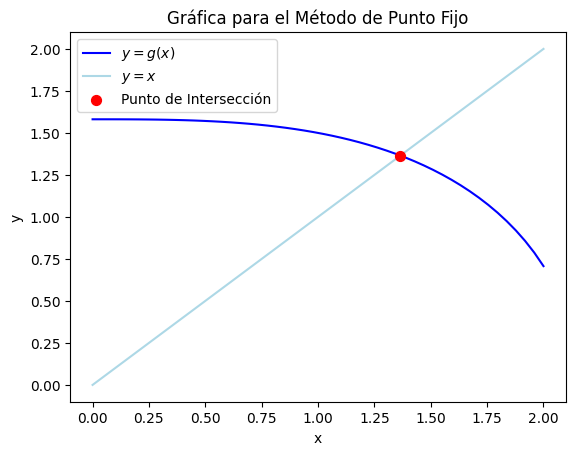

In [3]:
"""--------------------Gráfica g(x) y y=x-----------------------------"""
def g(x):
    return (1/2)*((10-x**3)**(1/2))


#Configurar el intervalo para la gráfica
xx=np.linspace(0,2)

#Graficar la función g(x) y la recta y = x
plt.plot(xx, g(xx), color="blue", label="$y=g(x)$")
plt.plot(xx, xx, color="lightblue", label="$y=x$")


plt.xlabel("x")
plt.ylabel("y")

#Etiquetas y ejes
plt.xlabel("x")
plt.ylabel("y")
plt.title("Gráfica para el Método de Punto Fijo")

#Punto intersección
#punto                                     size   capasup
plt.scatter(1.36523, 1.36523, color='red', s=50, zorder=5, label='Punto de Intersección')


#Muestra leyenda
plt.legend()
#Muestra gráfico
plt.show()

Un punto fijo para la función $g$ ocurre precisamente cuando la curva de $y=g(x)$ intersecta a la recta $y=x$

El punto rojo señala las coordenadas de intersección, lo cual representa gráficamente la raíz obtenida mediante el método de punto fijo

In [4]:
"""-----------------------DATOS DE ENTRADA---------------------------------------------"""
#Valores de Entrada
while True:
  try:
    po=float(input("Ingrese aproximación inicial: "))
    tol=float(input("Ingrese tolerancia: "))
    nmax_iter=int(input("Ingrese número máximo de iteraciones: "))
    if nmax_iter<0:
      print("El número máximo de iteraciones debe ser mayor que cero\n")
      continue
    else: break
  except ValueError:
    print("Los datos ingresados deben de ser de tipo flotante (po/tol) ó entero (n max iter)\n")
    continue


Ingrese aproximación inicial: 1.5
Ingrese tolerancia: 0.000001
Ingrese número máximo de iteraciones: 100


In [12]:
# Impresión de encabezado de la tabla
print("\nSe uso el ciclo While para calcular los siguientes valores:\n")
print(f"\n{'# n_iter':<10} {'p_n':<15} {'g(p_n)':<15} {'Error':<15}") #15 y 10 nos indican el ancho del espacio
print("-"*50)

#--------------------------------- MÉTODO PUNTO FIJO (Usando ciclo While)------------------------------------------------------------
iter=1
p=po
while iter<=nmax_iter:
  p_siguiente=g(p)
  error=abs(p_siguiente-p)

  #Imprimir la fila actual en la tabla
  print(f"{iter:<10} {p:<15.8f} {p_siguiente:<15.8f} {error:<15.8f}") #.8 nos indica la cantidad de decimales y f dato de num float

  if error<tol: #Paramos el ciclo cuando el error sea menor a la tolerancia
    print("-"*50)
    print(f"\nRaíz encontrada: {p_siguiente} en {iter} iteraciones")
    break

  p=p_siguiente
  iter+=1


if iter>nmax_iter: print(f"\nEl método fallo después de {nmax_iter} iteraciones")


Se uso el ciclo While para calcular los siguientes valores:


# n_iter   p_n             g(p_n)          Error          
--------------------------------------------------
1          1.50000000      1.28695377      0.21304623     
2          1.28695377      1.40254080      0.11558704     
3          1.40254080      1.34545837      0.05708243     
4          1.34545837      1.37517025      0.02971188     
5          1.37517025      1.36009419      0.01507606     
6          1.36009419      1.36784697      0.00775277     
7          1.36784697      1.36388700      0.00395996     
8          1.36388700      1.36591673      0.00202973     
9          1.36591673      1.36487822      0.00103852     
10         1.36487822      1.36541006      0.00053184     
11         1.36541006      1.36513782      0.00027224     
12         1.36513782      1.36527721      0.00013939     
13         1.36527721      1.36520585      0.00007136     
14         1.36520585      1.36524238      0.00003653     
1